In [18]:
import random
import importlib
from Math import vector as vector_module
from Math import matrix as matrix_module
from Math import grid as grid_module
from Geometry import mirror as mirror_module
from Geometry import hole as hole_module
from Geometry import cell_geometry as cell_geo_module
from Physics import lightray as lightray_module
from Physics import Physics as physics_module
from Core import gas_cell as gas_cell_module

for module in [vector_module, matrix_module, grid_module, physics_module, mirror_module, hole_module, cell_geo_module, lightray_module, gas_cell_module]:
    importlib.reload(module)

import math
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import traceback

from Math.vector import Vector
from Math.matrix import Matrix
from Math.grid import TwoGrid
from Geometry.mirror import Mirror
from Geometry.hole import Hole
from Geometry.cell_geometry import CellGeometry
from Physics.lightray import Lightray
from Physics.Physics import PhysicsUtils
from Core.gas_cell import GasCell
from Results.hitmap import Hitmap
from Results.trajectory_result import TrajectoryResult, TrajectoryResultsFromCSV
from Results.Config import Config


In [19]:
class FitnessEvaluator:
    def __init__(self, target_reflections, hole_diameter=0.4, entry_hole_diameter=0.4, initial_beam_diameter_cm=None):
        self.target_reflections = target_reflections
        self.target_u = 1.2
        self.target_v = 0.0
        self.hole_diameter = hole_diameter
        self.hole_radius = self.hole_diameter / 2.0

        self.entry_hole_u = -1.2
        self.entry_hole_v = 0.0
        self.entry_hole_diameter = entry_hole_diameter
        self.entry_hole_radius = self.entry_hole_diameter / 2.0

        self.initial_beam_diameter_cm = self.entry_hole_diameter if initial_beam_diameter_cm is None else initial_beam_diameter_cm

    def _find_hole_state(self, states):
        # Zoek naar een staat op M2 binnen de hole radius
        for state in states:
            if state.mirror_name == "M2":
                du = state.u - self.target_u
                dv = state.v - self.target_v
                if du * du + dv * dv <= self.hole_radius**2:
                    return state
        return None

    def _has_invalid_hole_reflection(self, states):
        for state in states:
            if getattr(state, 'event_type', 'reflection') != 'reflection':
                continue
            mirror_name = state.mirror_name.lower()
            if mirror_name == 'm1':
                du = state.u - self.entry_hole_u
                dv = state.v - self.entry_hole_v
                if du * du + dv * dv <= self.entry_hole_radius**2:
                    return True
            if mirror_name == 'm2':
                du = state.u - self.target_u
                dv = state.v - self.target_v
                if du * du + dv * dv <= self.hole_radius**2:
                    return True
        return False

    @staticmethod
    def _circle_intersection_area(r1, r2, d):
        if d >= r1 + r2:
            return 0.0
        if d <= abs(r1 - r2):
            return math.pi * min(r1, r2)**2

        r1_sq = r1 * r1
        r2_sq = r2 * r2
        alpha = 2.0 * math.acos((d*d + r1_sq - r2_sq) / (2.0 * d * r1))
        beta = 2.0 * math.acos((d*d + r2_sq - r1_sq) / (2.0 * d * r2))

        return 0.5 * (r1_sq * (alpha - math.sin(alpha)) + r2_sq * (beta - math.sin(beta)))

    def _beam_leak_penalty(self, states):
        """
        Bereken een continue straallek-penalty op basis van overlapgebied.
        Deze penalty is groter als meer van de beam overlapt met een gat of over de spiegelrand glijdt.
        """
        mirror_radius = 2.54  # cm, van TwoGrid(5.08, 5.08, 0.1) u_range/2
        initial_beam_diameter_cm = self.initial_beam_diameter_cm
        wavelength_mm = 1654e-6  # mm

        start_pos = Vector(0, 20, 25.0)
        current_pos = start_pos
        cumulative_path_cm = 0.0
        total_leak_area = 0.0

        for i, state in enumerate(states):
            if getattr(state, 'event_type', 'reflection') != 'reflection':
                continue

            segment_length = (state.position - current_pos).norm()
            cumulative_path_cm += segment_length
            current_pos = state.position

            beam_diameter_mm = PhysicsUtils.calculate_beam_diameter(
                wavelength=wavelength_mm,
                beam_diameter=initial_beam_diameter_cm * 10.0,
                distance_traveled=cumulative_path_cm * 10.0
            )
            beam_radius_cm = (beam_diameter_mm / 2.0) / 10.0
            beam_area = math.pi * beam_radius_cm * beam_radius_cm

            dist_to_center = math.hypot(state.u, state.v)
            mirror_overlap = self._circle_intersection_area(beam_radius_cm, mirror_radius, dist_to_center)
            total_leak_area += max(0.0, beam_area - mirror_overlap)

            if i < len(states) - 1:
                mirror_name = state.mirror_name.lower()
                if mirror_name == 'm1':
                    du = state.u - self.entry_hole_u
                    dv = state.v - self.entry_hole_v
                    dist_to_hole = math.hypot(du, dv)
                    total_leak_area += self._circle_intersection_area(beam_radius_cm, self.entry_hole_radius, dist_to_hole)
                elif mirror_name == 'm2':
                    du = state.u - self.target_u
                    dv = state.v - self.target_v
                    dist_to_hole = math.hypot(du, dv)
                    total_leak_area += self._circle_intersection_area(beam_radius_cm, self.hole_radius, dist_to_hole)

        return total_leak_area

    def calculate_score(self, track_memory):
        states = track_memory.memory
        if not states:
            return -1e12

        if self._has_invalid_hole_reflection(states):
            return -1e11

        # Meet echte reflecties en eventuele hole exit als eindgebeurtenis.
        reflection_count = sum(
            1 for state in states if getattr(state, 'event_type', 'reflection') == 'reflection'
        )
        hole_exit_state = next(
            (state for state in states if getattr(state, 'event_type', None) == 'hole_exit'),
            None
        )
        total_path_hits = reflection_count + (1 if hole_exit_state else 0)
        last_state = hole_exit_state if hole_exit_state else states[-1]

        # 1. CRUCIALE CHECK: Een valide geometrie mag alleen eindigen op M2.
        if last_state.mirror_name.lower() != "m2":
            return -5e9

        # Bonus voor correcte cycli: alleen paden met 3n+1 hits zijn echt geldig
        cycle_bonus = 0
        if total_path_hits >= 1 and total_path_hits % 3 == 1:
            n_circulations = (total_path_hits - 1) // 3
            cycle_bonus = 1e8 + (3e7 * n_circulations)

        # 2. Check of we het gat geraakt hebben (of in de buurt zijn)
        du = last_state.u - self.target_u
        dv = last_state.v - self.target_v
        dist = math.sqrt(du**2 + dv**2)

        # Basis score: afstand tot het gat.
        score = -dist * 1_000_000

        # 3. Bounce-Target Check
        bounce_diff = self.target_reflections - total_path_hits
        if bounce_diff > 0:
            score -= 1e7 * bounce_diff**2

        if total_path_hits == self.target_reflections:
            score += 5e7

        if total_path_hits > self.target_reflections:
            score -= (total_path_hits - self.target_reflections) * 150_000

        # 3n+1 bonus voor circulaties die op M2 eindigen
        score += cycle_bonus

        # Expliciete beloning voor een hole-exit versus een normale M2-reflectie.
        if hole_exit_state is not None:
            score += 7e8
            if dist <= self.hole_radius:
                score += (self.hole_radius - dist) * 3e8
                if dist <= self.hole_radius * 0.5:
                    score += 2e8
        else:
            if last_state.mirror_name.lower() == "m2":
                score += 6e7
                if dist <= self.hole_radius:
                    score += (self.hole_radius - dist) * 5e7
                else:
                    overflow = dist - self.hole_radius
                    score -= 3e8
                    score -= overflow * 3e8
                    score -= (overflow**2) * 4e8

        leak_area = self._beam_leak_penalty(states)
        if leak_area > 0.0:
            score -= 1e7 + 3e8 * leak_area

        return score

In [20]:
class SearchSpace:
    def __init__(self):
        # Basis posities (startpunt voor Hill-Climbing)
        self.m2_base = {"x": 42.5, "y": 7}
        self.m3_base = {"x": 37.5, "y": 32.0}

        # Basis hoeken (wordt geüpdatet bij elke nieuwe topscore)
        self.best_pitch = 0.0
        self.best_yaw = 0.0
        self.best_m2_phi = 0.0
        self.best_m2_theta = 0.0
        self.best_m3_phi = 0.0
        self.best_m3_theta = 0.0

        # Zoekbereik (wordt kleiner naarmate we dichterbij komen)
        self.pos_range = 2.5
        self.mirror_angle_range = 2
        self.ray_angle_range = 0.1

    def get_random_config(self):
        return {
            "m2_x": self.m2_base["x"] + random.uniform(-self.pos_range, self.pos_range),
            "m2_y": self.m2_base["y"] + random.uniform(-self.pos_range, self.pos_range),
            "m3_x": self.m3_base["x"] + random.uniform(-self.pos_range, self.pos_range),
            "m3_y": self.m3_base["y"] + random.uniform(-self.pos_range, self.pos_range),
            # Spiegel hoek offsets (phi = hor, theta = vert)
            "m2_phi": self.best_m2_phi + random.uniform(-self.mirror_angle_range, self.mirror_angle_range),
            "m3_theta": self.best_m3_theta + random.uniform(-self.mirror_angle_range, self.mirror_angle_range),
            # Laser start hoeken
            "ray_pitch": self.best_pitch + random.uniform(-self.ray_angle_range, self.ray_angle_range),
            "ray_yaw":  0 #+ random.uniform(-self.ray_angle_range, self.ray_angle_range),
        }
        

    def perturb(self, current_config):
        # Maak een nieuwe configuratie op basis van de huidige, met kleine willekeurige stappen
        new_cfg = current_config.copy()
        
        pos_limits = {
            "m2_x": (40, 45), 
            "m2_y": (5, 11),
            "m3_x": (35, 40), 
            "m3_y": (31, 35)
        }

        # Perturb positions
        for key, (low, high) in pos_limits.items():
                step = random.uniform(-self.pos_range, self.pos_range)
                if random.random() < 0.05: step *= 10
                new_cfg[key] = np.clip(new_cfg[key] + step, low, high)

        max_mirror_angle = 6
        for key in ["m2_phi", "m3_theta"]:
            step = random.uniform(-self.mirror_angle_range, self.mirror_angle_range)
            if random.random() < 0.05: step *= 10
            new_cfg[key] = np.clip(new_cfg[key] + step, -max_mirror_angle, max_mirror_angle)

        # Perturb laser angles MET harde grens
        max_ray_angle = 3
        for key in ["ray_pitch"]: #, "ray_yaw"]:
            step = random.uniform(-self.ray_angle_range, self.ray_angle_range)
            if random.random() < 0.05: step *= 10
            new_cfg[key] = np.clip(new_cfg[key] + step, -max_ray_angle, max_ray_angle)      

        # In perturb:
        new_cfg["ray_yaw"] = 0.0 # Forceer altijd 0
        return new_cfg

    def get_description(self, config):
        return (
            f"M2: ({config['m2_x']:.2f}, {config['m2_y']:.2f}) | "
            f"M3: ({config['m3_x']:.2f}, {config['m3_y']:.2f}) | "
            f"Ray: P:{config['ray_pitch']:.3f}°, Y:{config['ray_yaw']:.3f}°"
        )


In [21]:
class FindingGeometry:
    def __init__(self, target_reflections=28, iterations=500000, first_reflection_u=None, first_reflection_v=None, hole_diameter=0.4, entry_hole_diameter=0.4):
        self.search_space = SearchSpace()
        self.target_reflections = target_reflections
        self.iterations = iterations

        self.hole_diameter = hole_diameter
        self.hole_radius = hole_diameter / 2.0
        self.hole_u, self.hole_v = 1.2, 0.0

        self.entry_hole_diameter = entry_hole_diameter
        self.entry_hole_radius = entry_hole_diameter / 2.0
        self.entry_hole_u, self.entry_hole_v = -1.2, 0.0

        self.hole_local_pos = Vector(self.hole_u, self.hole_v, 0.0)
        self.entry_hole_local_pos = Vector(self.entry_hole_u, self.entry_hole_v, 0.0)
        self.first_reflection_u = first_reflection_u
        self.first_reflection_v = first_reflection_v

        self.evaluator = FitnessEvaluator(
            target_reflections,
            hole_diameter=self.hole_diameter,
            entry_hole_diameter=self.entry_hole_diameter,
            initial_beam_diameter_cm=self.entry_hole_diameter
        )

        # tracking
        self.best_score = -float("inf")
        self.best_config = None 
        self.best_track_memory = None

        self.current_score = -float("inf")
        self.current_config = None

        self.temperature = 1000
        self.cooling_rate = 0.9999

        self.no_improve_counter = 0  # counter voor stagnatie
        self.dist_no_improve_counter = 0  # extra counter voor afstand stagnatie
        self.last_dist = float("inf")  # laatste afstand tot het gat

        self.edge_lock_counter = 0
        self.pos_m1 = Vector(0, 20, 25.0)
    
    def _check_entry_hole_hit(self, track_memory):
        """
        Controleert of een reflectie op de entry hole op M1 is gevallen.
        Geeft True terug als er een ongeldig gat-contact is gevonden.
        """
        for state in track_memory.memory:
            if state.mirror_name.lower() == "m1":
                # Bereken afstand tot entry hole centrum (-1.2, 0.0)
                du = state.u - self.entry_hole_u
                dv = state.v - self.entry_hole_v
                dist = math.sqrt(du**2 + dv**2)
                
                if dist < self.entry_hole_radius:
                    return True  # Hit op entry hole gevonden!
        return False
        

    def _setup_cell(self, config):
        try:
            # 1. Posities bepalen
            pos_m1 = Vector(0, 20, 25.0)
            norm_m1 = Vector(1, 0, 0).normalize()
            pos_m2 = Vector(config["m2_x"], config["m2_y"], 25.0)
            pos_m3 = Vector(config["m3_x"], config["m3_y"], 25.0)
                       
            # Afstandscheck
            min_dist = 20.0
            if (pos_m2 - pos_m3).norm() < min_dist or \
               (pos_m1 - pos_m2).norm() < min_dist or \
               (pos_m1 - pos_m3).norm() < min_dist:
                return None, None, None # Geef 3 Nones terug (cell, pos_m2, ray_dir)

            # 2. Richtingen berekenen (Normalen)
            n2_base = PhysicsUtils.calculate_ideal_normal(pos_m1, pos_m2, pos_m3)
            rot_m2 = Matrix.rotation_z(math.radians(config["m2_phi"]))
            n2_final = (rot_m2 @ n2_base).normalize()
            n2_final.z = 0
            
            n3_base = PhysicsUtils.calculate_ideal_normal(pos_m2, pos_m3, pos_m1)
            rot_m3 = Matrix.rotation_z(math.radians(config["m3_theta"]))
            n3_final = (rot_m3 @ n3_base).normalize()
            n3_final.z = 0
                        
            #for name, n_vec in [("M2_base", n2_base), ("M3_base", n3_base)]:
            #    if abs(n_vec.z) > 1e-12:
            # Gebruik het lokale M2-coördinaat om de eerste reflectie te forceren.
            # Dit zorgt ervoor dat de startstraal naar het gewenste (u,v) punt op M2 gaat.
            mirror_target_u = config.get("target_u", self.first_reflection_u)
            mirror_target_v = config.get("target_v", self.first_reflection_v)

            if mirror_target_u is not None and mirror_target_v is not None:
                m2_tmp = Mirror("M2_temp", pos_m2, n2_final, TwoGrid(5.08, 5.08, 0.1), hole=None)
                u_dir, v_dir, _ = m2_tmp.get_local_axes()
                target_point = pos_m2 + (u_dir * mirror_target_u) + (v_dir * mirror_target_v)
            else:
                # Geen specifieke doelpunten opgegeven: fixeer de beam op het midden van M2 (u=0, v=0).
                target_point = pos_m2

            base_dir = (target_point - pos_m1).normalize()

            # Voeg de pitch/yaw variatie uit de config toe
            ray_dir = (
                Matrix.rotation_y(math.radians(config["ray_yaw"])) @ 
                Matrix.rotation_z(math.radians(config["ray_pitch"]))
            ) @ base_dir
            #if abs(ray_dir.z) > 1e-3:
            #    print(f"LEK GEVONDEN: ray_dir heeft Z-component: {ray_dir.z}")
            #    print(f"Config: {config}")
                
            # 4. Cell bouwen
            exit_hole = Hole("Exit", origin=self.hole_local_pos, radius=self.hole_radius, grid=None)
            entry_hole = Hole("Entry", origin=self.entry_hole_local_pos, radius=self.entry_hole_radius, grid=None)
            cell_geo = CellGeometry("Cell", cell_dimensions=(50, 40, 50))
            
            m1 = Mirror("M1", pos_m1, norm_m1, TwoGrid(5.08, 5.08, 0.1), reflection_coef=0.98, hole=entry_hole)
            m2 = Mirror("M2", pos_m2, n2_final, TwoGrid(5.08, 5.08, 0.1), reflection_coef=0.98, hole=exit_hole)
            m3 = Mirror("M3", pos_m3, n3_final, TwoGrid(5.08, 5.08, 0.1), reflection_coef=0.98)
            
            # Harde check op invoer-hoogte
            #if not (pos_m1.z == pos_m2.z == pos_m3.z == 25.0):
            #    print(f"Fout in basis-hoogte: M1={pos_m1.z}, M2={pos_m2.z}, M3={pos_m3.z}")

            for m in [m1, m2, m3]:
                cell_geo.add_mirror(m)
                
            # We geven alleen terug wat we echt nodig hebben voor de simulatie/score
            return GasCell(cell_geo), pos_m2, ray_dir

        except Exception as e:
            print("Fout in _setup_cell:", e)
            traceback.print_exc()
            return None, None, None

    def _compute_eval_state(self, track_mem):
        # Geef eerst een echte hole-exit voorkeur als die er is.
        hole_exit_state = next(
            (state for state in track_mem.memory if getattr(state, 'event_type', None) == 'hole_exit'),
            None
        )
        if hole_exit_state is not None:
            return hole_exit_state

        # Gebruik anders alleen de echte laatste staat van de simulatie.
        return track_mem.memory[-1]
    
    def _calculate_path_length(self, start_pos, states):
        if not states:
            return 0.0
        
        total_length = 0.0
        current_pos = start_pos
        
        for state in states:
            # Bereken afstand tussen vorig punt en huidig raakpunt
            segment_length = (state.position - current_pos).norm()
            total_length += segment_length
            current_pos = state.position # Update voor het volgende segment
            
        return total_length
    
      
    def run_optimization(self):
        self.acceptance = np.zeros(self.iterations)  # Voor het bijhouden van acceptatie ratio
        
        print(f"Start Optimalisatie | Target: {self.target_reflections} bounces op M2(u=1.2, v=0)")

        for i in range(self.iterations):
            config = self.search_space.get_random_config() if self.current_config is None else self.search_space.perturb(self.current_config)

            # Veel schonere aanroep:
            cell, pos_m2, ray_dir = self._setup_cell(config)
            
            if cell is None:
                #print(f"iter {i}: cell None")
                continue

            # Simulatie starten met de kant-en-klare ray_dir
            pos_m1 = Vector(0, 20, 25.0)
            track_mem = cell.run_simulation(
                Lightray(pos_m1 + (ray_dir * 0.01), ray_dir),
                max_reflections=self.target_reflections + 5
            )
            if not track_mem.memory:
                print(f"iter {i}: empty track memory")
                continue

            # Check: geen reflectie mag op de entry hole vallen!
            if self._check_entry_hole_hit(track_mem):
                # print(f"iter {i}: reflectie op entry hole gevonden - skip")
                continue

            for idx, state in enumerate(track_mem.memory):
                z_afwijking = abs(state.position.z - 25.0)
                if z_afwijking > 1e-3:
                   print(f"🚨 DRIFT GEVONDEN: Bounce {idx} op {state.mirror_name} wijkt af! Z={state.position.z}")
                    
            score = self.evaluator.calculate_score(track_mem)
            path_length = self._calculate_path_length(pos_m1, track_mem.memory)
            energy_diff = score - self.current_score
            
            metropolis_accept = math.exp(min(0, energy_diff / self.temperature))

            if (self.current_config is None) or (np.random.rand() < metropolis_accept):
                self.current_score = score
                self.current_config = config
                self.acceptance[i] = 1
                eval_state = self._compute_eval_state(track_mem)
                dist = math.sqrt((eval_state.u - self.hole_u) ** 2 + (eval_state.v - self.hole_v) ** 2)
                bounces = len(track_mem.memory)

                print(f"Iter {i:6d} | Bounces: {bounces:2d} | Dist: {dist:.4f} | Path: {path_length:.1f}cm | Score: {score:12.0f}| acceptence: {self.acceptance[:i+1].mean():.3f}")
                if abs(dist - self.hole_radius) < 0.005:  # Als de afstand dichtbij de radius komt
                    self.edge_lock_counter += 1
                else:
                    self.edge_lock_counter = 0

                improved_score = score > self.best_score + 1e-6
                improved_dist = dist < self.last_dist - 1e-5

                if improved_score or improved_dist:
                    self.best_score = max(self.best_score, score)
                    self.best_config = config
                    self.best_track_memory = track_mem
                    self.no_improve_counter = 0
                    self.dist_no_improve_counter = 0
                    self.last_dist = dist

                    # update search_space voor microscoping
                    self.search_space.m2_base = {"x": config["m2_x"], "y": config["m2_y"]}
                    self.search_space.m3_base = {"x": config["m3_x"], "y": config["m3_y"]}
                    self.search_space.best_m2_phi = config["m2_phi"]
                    self.search_space.best_m3_theta = config["m3_theta"]
                    self.search_space.best_pitch = config["ray_pitch"]
                    self.search_space.best_yaw = 0 # config["ray_yaw"]

                    # Microscope logic
                    if bounces < self.target_reflections:
                        self.search_space.pos_range = 1.0
                        self.search_space.mirror_angle_range = 0.5
                        self.search_space.ray_angle_range = 0.2
                    elif dist >= 1.0:
                        self.search_space.pos_range = 0.3
                        self.search_space.mirror_angle_range = 0.3
                        self.search_space.ray_angle_range = 0.14
                    elif dist >= 0.3:
                        self.search_space.pos_range = 0.01
                        self.search_space.mirror_angle_range = 0.01
                        self.search_space.ray_angle_range = 0.005
                    else:
                        self.search_space.pos_range = 0.01
                        self.search_space.mirror_angle_range = 0.01
                        self.search_space.ray_angle_range = 0.005
                else:
                    # verhoog counters als geen verbetering
                    self.no_improve_counter += 1
                    self.dist_no_improve_counter += 1

                # Early stop bij perfecte oplossing
                if dist < 0.01 and bounces >= self.target_reflections:
                    print("\n🎯 OPTIMALISATIE VOLTOOID: Exacte middelpunt gevonden.")
                    break

                # edge lock reset
                # wanneer we te lang op de rand van het gat blijven hangen, resetten we om uit die situatie te komen
                if self.edge_lock_counter > 10:
                    print("RESET: stuck on hole boundary")
                    self.current_config = None
                    self.temperature = 3.0
                    self.no_improve_counter = 0
                    self.dist_no_improve_counter = 0
                    self.edge_lock_counter = 0
                    self.last_dist = float("inf")
                    print("New initial conditions applied!")
                    print(f"New initial config: {self.current_config}")
                    print(f"New temperature: {self.temperature}")

        return self.best_config, self.best_track_memory
    
    def plot_geometry(self, config, track_memory, cell_dims=(50, 40, 50)):
            fig = plt.figure(figsize=(14, 10))
            ax = fig.add_subplot(111, projection='3d')

            # 1. Cel grenzen
            l, w, h = cell_dims
            for z in [0, h]:
                ax.plot([0, l, l, 0, 0], [0, 0, w, w, 0], [z, z, z, z, z], color='black', alpha=0.2)
            for x, y in [(0,0), (l,0), (l,w), (0,w)]:
                ax.plot([x, x], [y, y], [0, h], color='black', alpha=0.1)

            # 2. Bereken de werkelijke normalen zoals de simulatie dat doet
            pos_m1 = Vector(0, 20, 25.0)
            pos_m2 = Vector(config["m2_x"], config["m2_y"], 25.0)
            pos_m3 = Vector(config["m3_x"], config["m3_y"], 25.0)

            n2_base = PhysicsUtils.calculate_ideal_normal(pos_m1, pos_m2, pos_m3)
            n3_base = PhysicsUtils.calculate_ideal_normal(pos_m2, pos_m3, pos_m1)

            rot_m2 = Matrix.rotation_z(math.radians(config["m2_phi"]))
            rot_m3 = Matrix.rotation_z(math.radians(config["m3_theta"]))

            n1_final = Vector(1, 0, 0) # M1 kijkt altijd naar rechts
            n2_final = (rot_m2 @ n2_base).normalize()
            n3_final = (rot_m3 @ n3_base).normalize()

            # 3. Verbeterde Helper functie voor de spiegel-schijf
            def draw_actual_mirror(pos, normal_vec, color, label, radius=2.5):
                # Maak een cirkel in het YZ-vlak (normaal = X)
                t = np.linspace(0, 2*np.pi, 50)
                y_pts = radius * np.cos(t)
                z_pts = radius * np.sin(t)
                x_pts = np.zeros_like(t)

                # Bereken de rotatie om de X-as cirkel uit te lijnen met de werkelijke normaal vector
                # We gebruiken een eenvoudige quiver voor de pijl die de 'normaal' uit de simulatie volgt
                ax.quiver(pos.x, pos.y, pos.z, 
                        normal_vec.x, normal_vec.y, normal_vec.z, 
                        length=5, color=color, pivot='tail', linewidth=2)
                
                # Voor de schijf zelf plotten we nu een scatter/vlak dat loodrecht staat op de normaal
                ax.scatter(pos.x, pos.y, pos.z, color=color, s=200, label=label, edgecolors='black')
            
            path_length = self._calculate_path_length(self.pos_m1, track_memory)

            # Teken de spiegels met hun ECHTE normalen
            draw_actual_mirror(pos_m1, n1_final, 'red', 'M1 (In)')
            draw_actual_mirror(pos_m2, n2_final, 'green', 'M2 (Exit)')
            draw_actual_mirror(pos_m3, n3_final, 'blue', 'M3')

            # 4. Het pad en het gat (ongewijzigd)
            if track_memory and track_memory.memory:
                points = [(pos_m1.x, pos_m1.y, pos_m1.z)]
                for state in track_memory.memory:
                    points.append((state.position.x, state.position.y, state.position.z))
                path = np.array(points)
                ax.plot(path[:, 0], path[:, 1], path[:, 2], color='orange', alpha=0.7, label='Ray Path')

            hole_x = config["m2_x"] + self.hole_u
            hole_y = config["m2_y"] + self.hole_v
            ax.scatter(hole_x, hole_y, 25.0, color='purple', s=100, label='Target Hole')

            ax.set_box_aspect([l, w, h])
            ax.legend()
            ax.set_title('Path Length: ', path_length, ', Reflections: ', len(track_memory))
            plt.show()
            plt.savefig(f"geometry_{self.target_reflections}_bounces.png", dpi=300)
    
    # save best configuration and track memory for later analysis
    def save_results(self, filename_prefix="best_geometry"):
        if self.best_config is None or self.best_track_memory is None:
            print("No results to save.")
            return
        
        # Save configuration
        config_df = pd.DataFrame([self.best_config])
        config_df.to_csv(f"{filename_prefix}_{self.target_reflections}_config.csv", index=False)
        
        # Save track memory
        track_data = [{
            "mirror_name": state.mirror_name,
            "position_x": state.position.x,
            "position_y": state.position.y,
            "position_z": state.position.z,
            "u": state.u,
            "v": state.v
        } for state in self.best_track_memory.memory]
        
        track_df = pd.DataFrame(track_data)        
        print(f"Results saved: {filename_prefix}_{self.target_reflections}_config.csv and {filename_prefix}_{self.target_reflections}track_memory.csv")

        track_df.to_csv(f"{filename_prefix}_{self.target_reflections}_track_memory.csv", index=False)

In [35]:
finder = FindingGeometry(target_reflections=22, iterations=100000, first_reflection_u=-2, first_reflection_v=0.0, hole_diameter=0.4, entry_hole_diameter=0.36)
best_cfg, best_mem = finder.run_optimization()

if best_mem is None or not getattr(best_mem, 'memory', None):
    print("Geen geldig spoor gevonden. Controleer of de simulatie wel reflecties produceert.")
else:
    for i, state in enumerate(best_mem.memory):
        print(f"Bounce {i+1} op {state.mirror_name}: u={state.u:.4f}, v={state.v:.4f}, Global Z={state.position.z:.4f}")

Start Optimalisatie | Target: 22 bounces op M2(u=1.2, v=0)
Iter      0 | Bounces:  1 | Dist: 3.1152 | Path: 46.2cm | Score:  -8837024404| acceptence: 1.000
Iter      2 | Bounces:  1 | Dist: 3.1138 | Path: 45.8cm | Score:  -8823459426| acceptence: 0.667
Iter      3 | Bounces:  1 | Dist: 1.8949 | Path: 44.2cm | Score:  -6219474953| acceptence: 0.750
Iter      4 | Bounces:  1 | Dist: 1.8504 | Path: 44.5cm | Score:  -6136437919| acceptence: 0.800
Iter      5 | Bounces:  1 | Dist: 1.6418 | Path: 45.4cm | Score:  -5815696019| acceptence: 0.833
Iter      6 | Bounces:  1 | Dist: 1.5501 | Path: 45.2cm | Score:  -5685738811| acceptence: 0.857
Iter      8 | Bounces:  1 | Dist: 1.5261 | Path: 44.4cm | Score:  -5652790242| acceptence: 0.778
Iter      9 | Bounces:  2 | Dist: 1.3321 | Path: 71.3cm | Score:  -5000000000| acceptence: 0.800
Iter     10 | Bounces:  2 | Dist: 0.9767 | Path: 72.7cm | Score:  -5000000000| acceptence: 0.818
Iter     11 | Bounces:  2 | Dist: 1.2269 | Path: 71.8cm | Score:  -5

In [23]:
print(finder.best_config)
finder.save_results()
#finder.plot_geometry(best_cfg,best_mem, cell_dims=(50,40,30))

{'m2_x': np.float64(40.09325543281055), 'm2_y': np.float64(6.143194737156254), 'm3_x': np.float64(38.296383920365884), 'm3_y': np.float64(31.042935244428172), 'm2_phi': np.float64(0.4652645684287355), 'm3_theta': np.float64(-0.22012612060306597), 'ray_pitch': np.float64(-0.2497662380873494), 'ray_yaw': 0.0}
Results saved: best_geometry_19_config.csv and best_geometry_19track_memory.csv


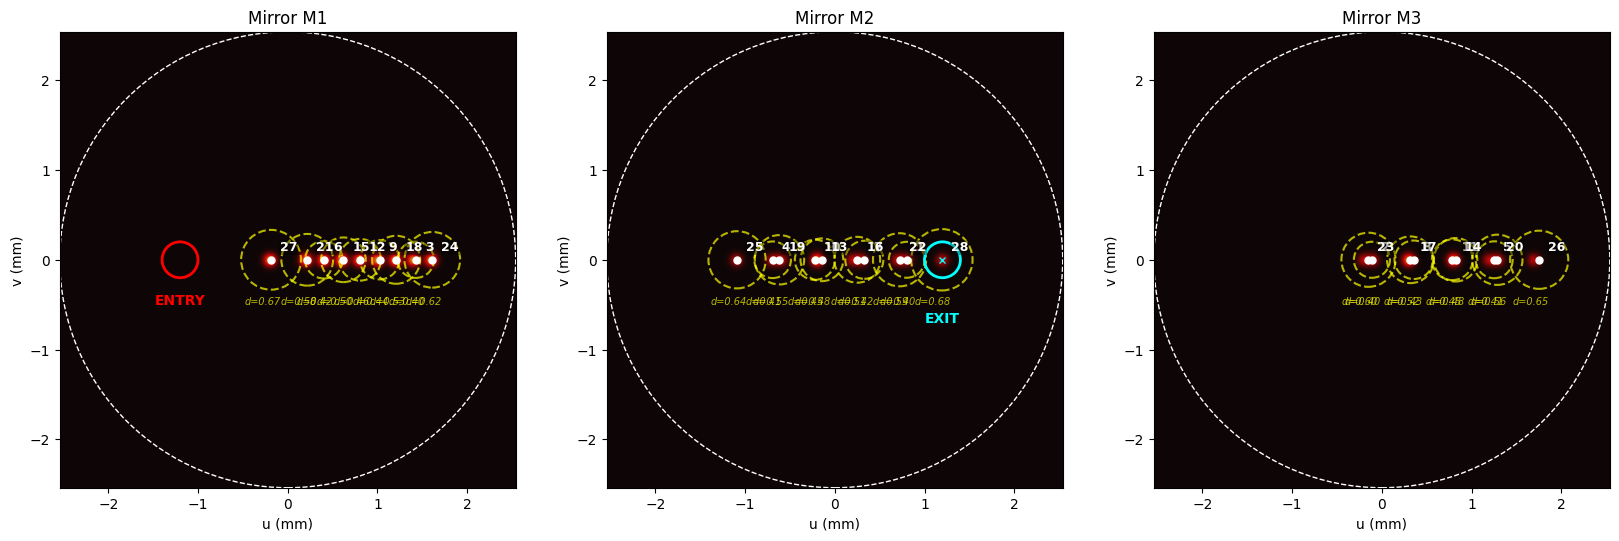

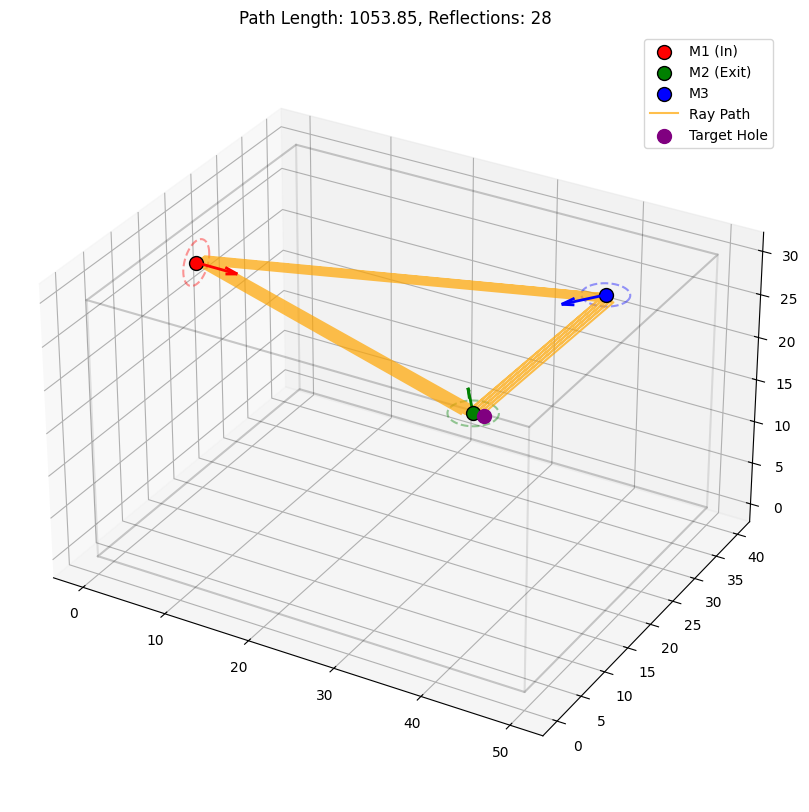

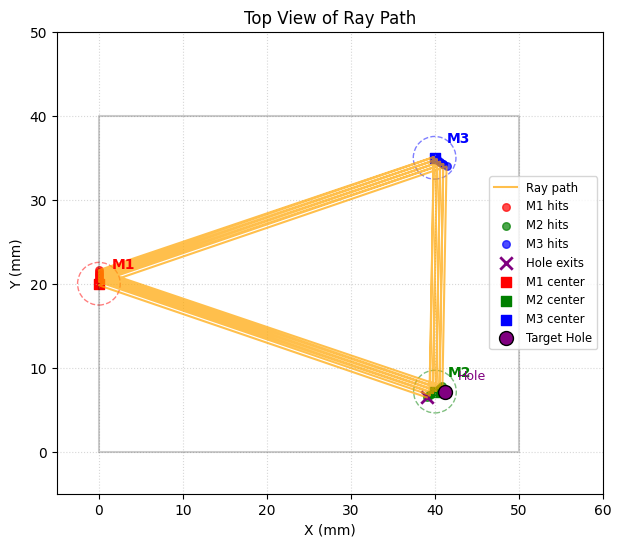

Results saved: geometry_28_config.csv and geometry_28_track_memory.csv
[0.4005868749499716, 0.4016717706144289, 0.40429811852250436, 0.40819271955642045, 0.4112255699621804, 0.4170989783962768, 0.4238870149477424, 0.42895655323755266, 0.4375445058970143, 0.44707446950017005, 0.4536629848887185, 0.46473434783568185, 0.4764738607878704, 0.48442506732909524, 0.4975269452747161, 0.5110067151603019, 0.5202384941998981, 0.5348078220168329, 0.5500102363597958, 0.5597606409730875, 0.5759518804049699, 0.5919274797465119, 0.6030094778346587, 0.6197545764862198, 0.6372848356117427, 0.6480715335075684, 0.6663390401616535, 0.6838321550638463]
Intensity after reflections: 0.5679761759500592
final intensity detected: 0.2814664341496481


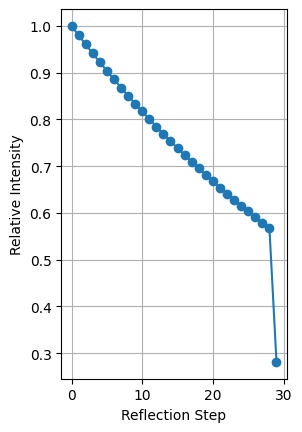

In [36]:
# trying the new trajectory_result classes
best_config = Config(**best_cfg)

tr = TrajectoryResult(best_mem, best_config, grid=TwoGrid(5.08, 5.08, 0.1))
tr.analyze_trajectory()
diameters = tr.calculate_beam_diameters()
print(diameters)
intensity = tr.analyze_intensity(diameters[-1])


What to fix: 
- Fix that we can set the first reflection on m2 (CHECK)
- Amount of reflections must always be 3n+1, with n the amount of circulations (CHECK)
- The final reflection actually has to go into the freaking hole... (CHECK)
- Have a look at integrating the Config datatype into the code.
- Also add the ENTRY HOLE to the optimalization, we cant have the lightray hit that 
  during one of its reflections of course....

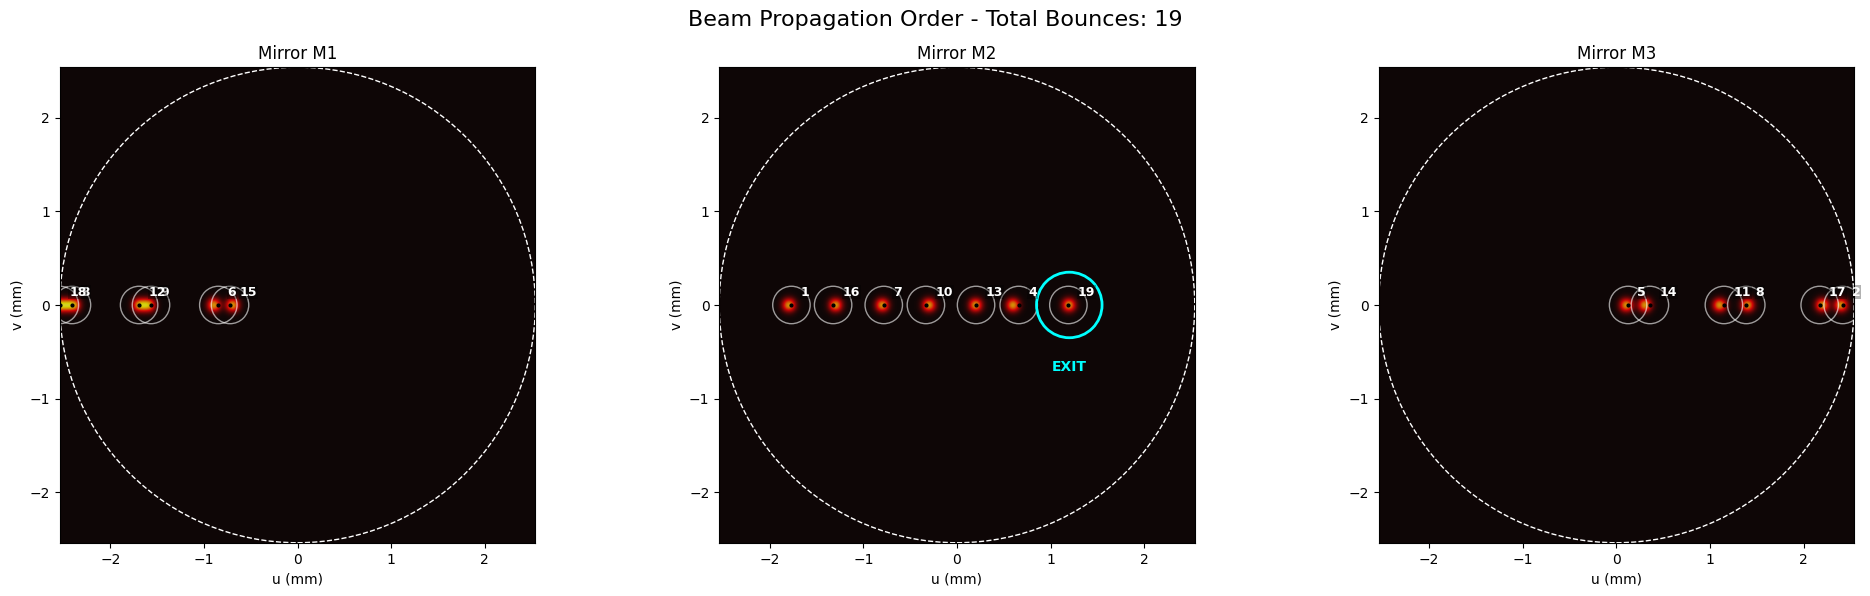

In [25]:
def plot_mirror_hitmaps_with_order(config, track_memory, grid_info, beam_diameter=0.4):
    """
    Plot de hitmaps inclusief volgnummers van de inslagen.
    beam_size geeft de straal van de ingestelde bundel op de spiegeloppervlakken.
    """
    # 1. Initialiseer Hitmaps
    hitmaps = {
        "M1": Hitmap("M1", grid_info),
        "M2": Hitmap("M2", grid_info),
        "M3": Hitmap("M3", grid_info)
    }

    # 2. Plot instellen
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    mirror_names = ["M1", "M2", "M3"]
    
    # We houden bij hoeveel hits er per spiegel zijn voor de tekst-offset
    # (zodat nummers elkaar niet perfect overlappen)
    mirror_hit_counts = {"M1": 0, "M2": 0, "M3": 0}

    # 3. Vul de hitmaps EN teken de nummers
    if track_memory and track_memory.memory:
        for idx, state in enumerate(track_memory.memory):
            name = state.mirror_name
            if name in hitmaps:
                # Registreer in de data matrix voor de heatmap-kleur
                hitmaps[name].register_hit(state.u, state.v)
                
                # Bepaal in welke subplot we moeten tekenen
                ax_idx = mirror_names.index(name)
                ax = axes[ax_idx]
                
                # Teken het volgnummer (idx + 1 omdat we bij 1 willen beginnen)
                # We voegen een kleine offset toe zodat het nummer naast de 'hit' staat
                ax.text(state.u + 0.1, state.v + 0.1, str(idx + 1), 
                        color='white', fontsize=9, fontweight='bold',
                        bbox=dict(facecolor='black', alpha=0.3, edgecolor='none', pad=0.5))
                
                # Teken een klein stipje voor de exacte hit
                ax.plot(state.u, state.v, 'ko', markersize=2)
                
                # Teken de beam radius als cirkel als deze is ingesteld
                if beam_diameter and beam_diameter > 0:
                    beam_circle = plt.Circle((state.u, state.v), beam_diameter / 2, edgecolor='white', facecolor='none', linestyle='-', linewidth=1, alpha=0.6)
                    ax.add_artist(beam_circle)

    # 4. Heatmap styling
    for i, name in enumerate(mirror_names):
        hm = hitmaps[name]
        img_data = np.array(hm.data).T 
        extent = [-grid_info.u_range/2, grid_info.u_range/2, 
                  -grid_info.v_range/2, grid_info.v_range/2]
        
        im = axes[i].imshow(img_data, extent=extent, origin='lower', 
                            cmap='hot', interpolation='gaussian', alpha=0.8)
        
        # Teken spiegelrand
        circle = plt.Circle((0, 0), grid_info.u_range/2, color='white', fill=False, linestyle='--')
        axes[i].add_artist(circle)
        
        if name == "M2":
            # Teken het gat op M2 (u=1.2, v=0)
            hole_circle = plt.Circle((1.2, 0.0), 0.35, color='cyan', fill=False, linewidth=2)
            axes[i].add_artist(hole_circle)
            axes[i].annotate("EXIT", xy=(1.2, -0.7), color='cyan', ha='center', fontweight='bold')

        axes[i].set_title(f"Mirror {name}")
        axes[i].set_xlabel("u (mm)")
        axes[i].set_ylabel("v (mm)")
        axes[i].set_facecolor('#222222') # Donkere achtergrond voor contrast

    plt.suptitle(f"Beam Propagation Order - Total Bounces: {len(track_memory.memory)}", fontsize=16)
    plt.tight_layout()
    plt.show()  
    
mirror_grid = TwoGrid(5.08, 5.08, 0.1) 
plot_mirror_hitmaps_with_order(best_cfg, best_mem, mirror_grid, beam_diameter=0.4)

In [ ]:
def run_multiple_optimizations(n_runs=100, target_reflections=16, iterations=100_000):
    results = []

    for run in range(n_runs):
        print(f"\n=== RUN {run + 1}/{n_runs} ===")

        finder = FindingGeometry(target_reflections=target_reflections, iterations=iterations)

        best_cfg, best_mem = finder.run_optimization()

        if best_cfg is None or best_mem is None or not best_mem.memory:
            print("Run failed, skipping...")
            continue

        eval_state = finder._compute_eval_state(best_mem)

        dist = math.sqrt((eval_state.u - finder.hole_u) ** 2 + (eval_state.v - finder.hole_v) ** 2)

        bounces = len(best_mem.memory)

        target_found = (bounces >= target_reflections) and (dist < 0.01)

        iterations_used = finder.iterations

        row = {
            **best_cfg,
            "bounces": bounces,
            "dist": dist,
            "iterations_used": iterations_used,
            "target_found": target_found,
        }

        results.append(row)

    return pd.DataFrame(results)


#df = run_multiple_optimizations(n_runs=100)
#print(df.head())


=== RUN 1/100 ===
Start Optimalisatie | Target: 16 bounces op M2(u=1.2, v=0)
Iter      0 | Bounces:  2 | Dist: 1.7638 | Path: 68.5cm | Score:  -5000000000| acceptence: 1.000
Iter      1 | Bounces:  2 | Dist: 0.9841 | Path: 68.5cm | Score:  -5000000000| acceptence: 1.000
Iter      2 | Bounces:  2 | Dist: 0.8594 | Path: 70.4cm | Score:  -5000000000| acceptence: 1.000
Iter      3 | Bounces:  5 | Dist: 0.3493 | Path: 180.8cm | Score:  -5000000000| acceptence: 1.000
Iter      4 | Bounces:  5 | Dist: 2.7797 | Path: 182.8cm | Score:  -5000000000| acceptence: 1.000
Iter      5 | Bounces:  4 | Dist: 0.5584 | Path: 150.8cm | Score:  -1709442492| acceptence: 1.000
Iter     23 | Bounces:  4 | Dist: 0.1668 | Path: 152.3cm | Score:   -610197193| acceptence: 0.292
Iter     34 | Bounces:  4 | Dist: 0.0084 | Path: 151.1cm | Score:   -352513765| acceptence: 0.229
Iter    115 | Bounces:  4 | Dist: 0.0025 | Path: 151.0cm | Score:   -350763376| acceptence: 0.078
Iter   3117 | Bounces:  4 | Dist: 0.0000 | 

KeyboardInterrupt: 

pro's of switching to concave mirrors:
- It will significantly improve our experiment in path length, and SNR. 
Con's
- There are many parts of the program that have to be rewritten... Such as: the mirror and the twogrid (have to be concave, and I dont know how to make a non 2D surface, 2D for a hitmap), reflection events (the normal of the mirror is now radius dependent) and the lightray (since the normal is radius dependent, we must look at the whole beam differently, since at the border of the ray, the normal will be different than at the middle). Also, propagation is different since the beam now converges and diverges, instead of being approximated as constant. 
- plus, we must buy new mirrors

-> we could use a chief ray thingy, to exclude all the stuff with the beam place dependent reflections and stuff. 
-> maybe we could only make 2 mirrors concave to get a bit les expensive? 

What has to change for flat mirrors:
- The divergence of the beam should be taken into account. 
- We should pay more focus on the intensity of the end result. We cant have a reflection partially falling inside the hole, so it must not be to big. However, smaller holes will absorb less of the intensity of the final reflection/signal. We should try to optimize this. 
- We should also look at the amount of optical path length is actually needed, and make a weighted decision on the path length to the intensity. 